## All ones and ALl Zeros Tensors 

In [1]:
import tensorflow as tf
# Ones
x=tf.ones(shape=(2,1))
print(x)

tf.Tensor(
[[1.]
 [1.]], shape=(2, 1), dtype=float32)


In [2]:
# Zeros
x=tf.zeros(shape=(2,1))
print(x)

tf.Tensor(
[[0.]
 [0.]], shape=(2, 1), dtype=float32)


## Random Tensors

In [3]:
x= tf.random.normal(shape=(3,1), mean=0, stddev=1.)
print(x)

tf.Tensor(
[[-1.4211462 ]
 [-0.84728235]
 [ 0.18015552]], shape=(3, 1), dtype=float32)


In [4]:
x=tf.random.uniform(shape=(3,1), minval=0., maxval=1.)
print(x)

tf.Tensor(
[[0.3185593 ]
 [0.24844897]
 [0.49622953]], shape=(3, 1), dtype=float32)


### Creating a tensorflow variable

In [5]:
v= tf.Variable(initial_value=tf.random.normal(shape=(3,1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[-0.04028651],
       [ 0.89584154],
       [-0.30760542]], dtype=float32)>


## Assigning a value to a TensorFlow variable

In [6]:
v.assign(tf.ones((3,1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

### Assigning a value to a subset of a tensorflow variable

In [7]:
v[0,0].assign(3.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

## Using assign_add()

In [8]:
v.assign_add(tf.ones((3,1)))  # Add 1 to each component

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>

## Using the GradientTape

In [9]:
input_var=tf.Variable(initial_value=3.)
with tf.GradientTape() as tape:
    result=tf.square(input_var)
    gradient=tape.gradient(result, input_var)

## Using NEsted gradient tapes to compute second-order gradients

In [10]:
time= tf.Variable(0.)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position =4.9 * time ** 2
        speed =inner_tape.gradient(position,time)
        acceleration=outer_tape.gradient(speed, time)

print(speed)
print(acceleration)

tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(9.8, shape=(), dtype=float32)


##  Generating two classes of random points in a 2D plane

In [11]:
import numpy as np

In [12]:
num_samples_per_class = 1000 
negative_samples = np.random.multivariate_normal(  
    mean=[0, 3],   # The center of the distribution is at the point (0, 3) in 2D space. This is the "average" location of the samples.
    cov=[[1, 0.5],[0.5, 1]],   
    size=num_samples_per_class)  
positive_samples = np.random.multivariate_normal(  
    mean=[3, 0],   
    cov=[[1, 0.5],[0.5, 1]],  
    size=num_samples_per_class)

print(negative_samples)

[[ 0.21565572  3.69908621]
 [-0.1834217   3.31121203]
 [-0.38264251  1.71975222]
 ...
 [-0.68823406  1.57136652]
 [ 0.76981664  3.70779166]
 [ 0.16728797  4.34341122]]


## Stacking the two classes into an array with shape (2000, 2)

In [13]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)
print(inputs)

[[ 0.21565571  3.6990862 ]
 [-0.1834217   3.311212  ]
 [-0.3826425   1.7197522 ]
 ...
 [ 3.9740746   0.85638577]
 [ 2.7971532  -0.05177507]
 [ 3.487552   -0.19514413]]


## Generating the corresponding targets (0 and 1)

In [14]:
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
             np.ones((num_samples_per_class, 1), dtype="float32")))  # vstack work column-wise

## Plotting the two point classes

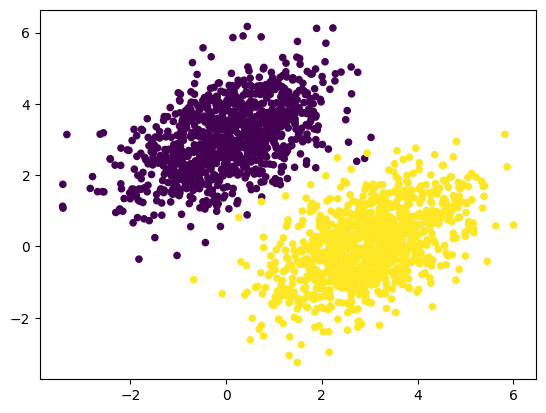

In [15]:
import matplotlib.pyplot as plt
plt.scatter(inputs[:,0], inputs[:,1],c=targets[:,0], s=20, alpha=1.0)
plt.show()

## Simple Classification of 0 and 1

In [24]:
# Dense Layer shape
input_dim=2
output_dim=1
# w is weight, connected with both input and output
# b is bias, connected with only bias
w=tf.Variable(initial_value=tf.random.uniform(shape=(input_dim,output_dim)))
b=tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

In [25]:
# Forward pass
def model(inputs):
    return tf.matmul(inputs, w) + b

In [26]:
# MSE loss function
def square_loss(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

In [27]:
# Training step function

learning_rate =0.1
def training_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions =model(inputs)
        loss=square_loss(predictions, targets)
    grad_loss_wrt_w, grad_loss_wrt_b= tape.gradient(loss, [w,b])
    w.assign_sub(grad_loss_wrt_w * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

## Batch Training loop
####  our targets are zeros and ones, a given input point will be classified as “0” if its prediction value is below 0.5, and as “1” if it is above 0.5

In [28]:
for step in range(40):
    loss =training_step(inputs, targets)
    print(f"Loss at step {step}: {loss: .4f}")

Loss at step 0:  4.6948
Loss at step 1:  0.6541
Loss at step 2:  0.2168
Loss at step 3:  0.1454
Loss at step 4:  0.1271
Loss at step 5:  0.1171
Loss at step 6:  0.1089
Loss at step 7:  0.1015
Loss at step 8:  0.0948
Loss at step 9:  0.0887
Loss at step 10:  0.0832
Loss at step 11:  0.0781
Loss at step 12:  0.0735
Loss at step 13:  0.0693
Loss at step 14:  0.0655
Loss at step 15:  0.0620
Loss at step 16:  0.0588
Loss at step 17:  0.0558
Loss at step 18:  0.0532
Loss at step 19:  0.0508
Loss at step 20:  0.0486
Loss at step 21:  0.0465
Loss at step 22:  0.0447
Loss at step 23:  0.0430
Loss at step 24:  0.0415
Loss at step 25:  0.0401
Loss at step 26:  0.0388
Loss at step 27:  0.0377
Loss at step 28:  0.0366
Loss at step 29:  0.0357
Loss at step 30:  0.0348
Loss at step 31:  0.0340
Loss at step 32:  0.0333
Loss at step 33:  0.0326
Loss at step 34:  0.0320
Loss at step 35:  0.0314
Loss at step 36:  0.0309
Loss at step 37:  0.0305
Loss at step 38:  0.0300
Loss at step 39:  0.0297


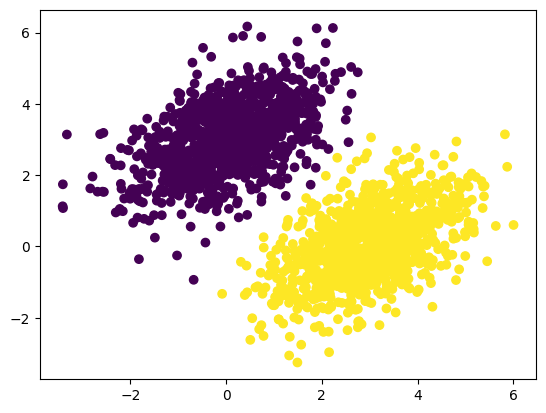

In [30]:
# Visualize
predictions= model(inputs)
plt.scatter(inputs[:,0], inputs[:,1], c=predictions[:,0]>0.5)
plt.show()

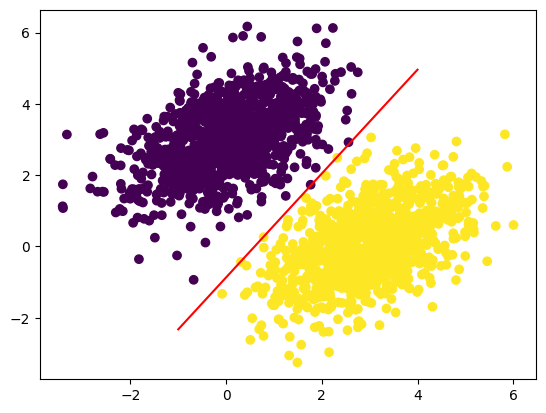

In [31]:
# Split line

x=np.linspace(-1, 4, 100)
y=-w[0] / w[1] *x + (0.5 -b) / w[1]
plt.plot(x,y, "-r")
plt.scatter(inputs[:,0], inputs[:,1], c=predictions[:,0] > 0.5)

## Implementing a Dense Layer

In [35]:
from tensorflow import keras
class SimpleDense(keras.layers.Layer):
    
    def __init__(self, units, activation=None):
        super().__init__()
        self.units= units
        self.activation =activation

    def build(self, input_shape):
        input_dim=input_shape[-1]
        self.w=self.add_weight(shape=(input_dim, self.units),
                              initializer="random_normal")
        self.b=self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs):
            y=tf.matmul(inputs, self.w)+self.b
            if self.activation is not None:
                y=self.activation(y)
            return y

In [36]:
my_dense=SimpleDense(units=32, activation=tf.nn.relu)
input_tensor=tf.ones(shape=(2,784))
output_tensor=my_dense(input_tensor)
print(output_tensor.shape)

(2, 32)


In [ ]:
from tensorflow.keras import layers
layer=layers.Dense(32, activation="relu")
from tensorflow.keras import models
from tensorflow.keras import layers
model=models.Sequential([
    layers.Dense(32, activation="relu"),
    layers.Dense(32)
])

In [38]:
model = NaiveSequential([
    NaiveDense(input_size=784, output_size=32, activation="relu"),
    NaiveDense(input_size=32, output_size=64, activation="relu"),
    NaiveDense(input_size=64, output_size=32, activation="relu"),
    NaiveDense(input_size=32, output_size=10, activation="softmax")
])

NameError: name 'NaiveSequential' is not defined